# 02 - Baseline Models for Daily Volatility Forecasting

---

## 1. Objective and Scope

This notebook establishes simple baseline models for daily realized volatility forecasting. These baselines act as lower bounds and sanity checks against which all structural and neural models will be evaluated.

No attempt is made to optimize or tune these models. Their role is purely diagnostic.

**Key principles:**
- One-step-ahead forecasting only
- Same target and evaluation setup as all later notebooks
- Regime-conditional evaluation using fixed regime labels from Notebook 01

These baselines are intentionally simplistic and are not expected to capture structural volatility dynamics. Their purpose is to establish lower bounds, not to model the data-generating process. More sophisticated models (HAR, GARCH, LSTM, Transformer) are introduced in later notebooks.

---

## 2. Setup and Data Loading

### 2.1 Imports and Configuration

In [1]:
# Standard library
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Project modules
PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src.data.rv_utils import load_processed_rv
from src.models.baselines import (
    generate_all_baseline_forecasts,
    forecast_persistence,
    forecast_rolling_average,
    forecast_ewma,
    align_forecasts_with_actuals
)
from src.evaluation.metrics import (
    compute_metrics,
    compute_metrics_by_regime,
    format_metrics_table
)
from src.utils.baseline_plotting import (
    plot_baseline_forecasts_timeseries,
    plot_metrics_comparison,
    plot_regime_conditional_metrics,
    plot_forecast_error_distribution
)
from src.utils.plotting import set_mpl_defaults
from src.utils.io import ensure_dir, save_dataframe

# Configuration
set_mpl_defaults()
np.random.seed(42)

# Paths
DATA_PROCESSED = Path("../data/processed")
FIG_DIR = ensure_dir(Path("../results/figures/baselines"))
RESULTS_DIR = ensure_dir(Path("../results"))
METRICS_DIR = ensure_dir(RESULTS_DIR / "metrics")

print("Setup complete!")

Setup complete!


### 2.2 Load Data

In [2]:
# Load realized volatility and regime labels
df = load_processed_rv(DATA_PROCESSED / "regimes.csv")

print(f"Data shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
display(df.head())

# Check regime distribution
print(f"\nRegime distribution:")
print(df['regime'].value_counts().sort_index())

Data shape: (5016, 3)
Date range: 2000-01-04 00:00:00 to 2019-12-31 00:00:00

Columns: ['rv', 'regime', 'trailing_rv']

First few rows:


,rv,regime,trailing_rv
date,,,
2000-01-04,0.000224,NaN,NaN
2000-01-05,0.000314,NaN,NaN
2000-01-06,0.000131,NaN,NaN
2000-01-07,0.000094,NaN,NaN
2000-01-10,0.000120,NaN,NaN



Regime distribution:
regime
High      1635
Low       1635
Medium    1684
Name: count, dtype: int64


### Interpretation:

We have 5,016 observations spanning 20 years (2000-2019). The first 62 observations lack regime labels due to the 63-day trailing window requirement. The three regimes (Low, Medium, High) are approximately balanced, as expected from the tertile-based threshold selection in NB01.

---

## 3. Baseline Model 1: Persistence

### 3.1 Motivation

Volatility exhibits strong persistence - today's volatility is highly predictive of tomorrow's volatility. The persistence baseline assumes tomorrow's realized volatility equals today's:

$$
\widehat{\text{RV}}_t = \text{RV}_{t-1}
$$

This naive forecast is surprisingly difficult to beat and serves as the most important lower bound.

### 3.2 Implementation

In [3]:
# Generate persistence forecasts
persistence_fcst = forecast_persistence(df['rv'], name='persistence')

# Display first few forecasts
print("Persistence forecasts (first 10):")
print(pd.DataFrame({
    'date': df.index[:10],
    'rv_actual': df['rv'][:10],
    'forecast': persistence_fcst[:10]
}))

print(f"\nNumber of non-NaN forecasts: {persistence_fcst.notna().sum()}")

Persistence forecasts (first 10):
                 date  rv_actual  forecast
date                                      
2000-01-04 2000-01-04   0.000224       NaN
2000-01-05 2000-01-05   0.000314  0.000224
2000-01-06 2000-01-06   0.000131  0.000314
2000-01-07 2000-01-07   0.000094  0.000131
2000-01-10 2000-01-10   0.000120  0.000094
2000-01-11 2000-01-11   0.000068  0.000120
2000-01-12 2000-01-12   0.000123  0.000068
2000-01-13 2000-01-13   0.000101  0.000123
2000-01-14 2000-01-14   0.000139  0.000101
2000-01-18 2000-01-18   0.000093  0.000139

Number of non-NaN forecasts: 5015


### 3.3 Expected Behavior

The persistence baseline should:
- Perform well in calm, stable regimes where volatility changes slowly
- Lag behind during volatility spikes (always one day behind)
- Show strong regime dependence (better in Low regime, worse in High regime)

---

## 4. Baseline Model 2: Rolling Average

### 4.1 Motivation

Simple averaging can smooth noise while retaining interpretability. The rolling average baseline uses the mean of the past $W$ days:

$$
\widehat{\text{RV}}_t = \frac{1}{W} \sum_{i=1}^{W} \text{RV}_{t-i}
$$

We use $W = 5$ days (approximately one trading week) to balance smoothness with responsiveness.

### 4.2 Implementation

In [4]:
# Generate rolling average forecasts
ROLLING_WINDOW = 5

rolling_fcst = forecast_rolling_average(
    df['rv'], 
    window=ROLLING_WINDOW,
    name='rolling_avg'
)

print(f"Rolling average forecasts (W={ROLLING_WINDOW}):")
print(f"First non-NaN forecast at index: {rolling_fcst.first_valid_index()}")
print(f"Number of non-NaN forecasts: {rolling_fcst.notna().sum()}")

# Compare with persistence
comparison = pd.DataFrame({
    'rv_actual': df['rv'],
    'persistence': persistence_fcst,
    'rolling_avg': rolling_fcst
}).loc['2000-02':'2000-03']

print("\nSample comparison (Feb-Mar 2000):")
display(comparison.head(10))

Rolling average forecasts (W=5):
First non-NaN forecast at index: 2000-01-11 00:00:00
Number of non-NaN forecasts: 5011

Sample comparison (Feb-Mar 2000):


,rv_actual,persistence,rolling_avg
date,,,
2000-02-01,0.000117,0.000189,0.000180
2000-02-02,0.000094,0.000117,0.000168
2000-02-03,0.000148,0.000094,0.000173
2000-02-04,0.000068,0.000148,0.000165
2000-02-07,0.000060,0.000068,0.000123
2000-02-08,0.000091,0.000060,0.000097
2000-02-09,0.000093,0.000091,0.000092
2000-02-10,0.000117,0.000093,0.000092
2000-02-11,0.000103,0.000117,0.000086


### 4.3 Expected Behavior

The rolling average should:
- Produce smoother forecasts than persistence
- React more slowly to regime transitions
- Potentially underestimate during high-volatility periods
- Require 5 observations before producing forecasts

---

## 5. Baseline Model 3: EWMA

### 5.1 Motivation

EWMA (Exponentially Weighted Moving Average) introduces structured exponential decay while remaining simple. The recursive formula is:

$$
\widehat{\text{RV}}_t = \lambda \widehat{\text{RV}}_{t-1} + (1 - \lambda) \text{RV}_{t-1}
$$

We use $\lambda = 0.94$, the RiskMetrics standard for daily volatility, corresponding to an effective window of approximately 16 days.

### 5.2 Implementation

In [5]:
# Generate EWMA forecasts
EWMA_LAMBDA = 0.94

ewma_fcst = forecast_ewma(
    df['rv'],
    lambda_param=EWMA_LAMBDA,
    name='ewma'
)

print(f"EWMA forecasts (λ={EWMA_LAMBDA}):")
print(f"First non-NaN forecast at index: {ewma_fcst.first_valid_index()}")
print(f"Number of non-NaN forecasts: {ewma_fcst.notna().sum()}")

# Compare all three baselines
comparison_all = pd.DataFrame({
    'rv_actual': df['rv'],
    'persistence': persistence_fcst,
    'rolling_avg': rolling_fcst,
    'ewma': ewma_fcst
}).loc['2008-09':'2008-10']  # Financial crisis period

print("\nSample comparison (Sep-Oct 2008, Financial Crisis):")
display(comparison_all.head(15))

EWMA forecasts (λ=0.94):
First non-NaN forecast at index: 2000-01-04 00:00:00
Number of non-NaN forecasts: 5016

Sample comparison (Sep-Oct 2008, Financial Crisis):


,rv_actual,persistence,rolling_avg,ewma
date,,,,
2008-09-01 23:00:00,0.000152,0.000056,0.000069,0.000098
2008-09-02 23:00:00,0.000121,0.000152,0.000082,0.000102
2008-09-03 23:00:00,0.000145,0.000121,0.000093,0.000103
2008-09-04 23:00:00,0.000169,0.000145,0.000110,0.000105
2008-09-07 23:00:00,0.000650,0.000169,0.000129,0.000109
2008-09-08 23:00:00,0.000216,0.000650,0.000247,0.000142
2008-09-09 23:00:00,0.000184,0.000216,0.000260,0.000146
2008-09-10 23:00:00,0.000379,0.000184,0.000273,0.000148
2008-09-11 23:00:00,0.000208,0.000379,0.000320,0.000162


### 5.3 Expected Behavior

EWMA should:
- Adapt faster than rolling averages due to exponential weighting
- Be more stable than pure persistence
- Exhibit gradual decay after volatility spikes
- Balance recent information with long-term trends

---

## 6. Forecast Generation and Alignment

### 6.1 Generate All Forecasts

In [6]:
# Generate all baseline forecasts at once
forecasts = generate_all_baseline_forecasts(
    df['rv'],
    rolling_window=ROLLING_WINDOW,
    ewma_lambda=EWMA_LAMBDA
)

print("Generated forecasts for all baseline models:")
print(forecasts.info())

# Summary statistics
print("\nForecast summary statistics:")
display(forecasts.describe())

Generated forecasts for all baseline models:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5016 entries, 2000-01-04 00:00:00 to 2019-12-31 00:00:00
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   persistence  5015 non-null   float64
 1   rolling_avg  5011 non-null   float64
 2   ewma         5016 non-null   float64
dtypes: float64(3)
memory usage: 285.8 KB
None

Forecast summary statistics:


,persistence,rolling_avg,ewma
count,5015.000000,5011.000000,5016.000000
mean,0.000105,0.000105,0.000106
std,0.000240,0.000203,0.000165
min,0.000001,0.000003,0.000006
25%,0.000023,0.000027,0.000033
50%,0.000047,0.000052,0.000057
75%,0.000102,0.000105,0.000116
max,0.007748,0.003420,0.001760


### 6.2 Align with Actuals and Regimes

In [7]:
# Align forecasts with actuals for evaluation
forecasts_aligned, actuals_aligned = align_forecasts_with_actuals(
    forecasts,
    df['rv'],
    drop_na=True
)

print(f"Aligned evaluation sample:")
print(f"  Observations: {len(actuals_aligned)}")
print(f"  Date range: {actuals_aligned.index.min()} to {actuals_aligned.index.max()}")

# Add regimes to aligned data
eval_df = forecasts_aligned.copy()
eval_df['actual'] = actuals_aligned
eval_df['regime'] = df.loc[actuals_aligned.index, 'regime']

# Drop observations without regime labels (first 62 days)
eval_df = eval_df.dropna(subset=['regime'])

print(f"\nFinal evaluation sample (with regimes):")
print(f"  Observations: {len(eval_df)}")
print(f"  Date range: {eval_df.index.min()} to {eval_df.index.max()}")

# Save forecasts for downstream use
forecasts_output = eval_df[['persistence', 'rolling_avg', 'ewma', 'actual']].copy()
save_dataframe(forecasts_output, RESULTS_DIR / "forecasts" / "baseline_forecasts.csv")
print(f"\nSaved forecasts to: {RESULTS_DIR / 'forecasts' / 'baseline_forecasts.csv'}")

Aligned evaluation sample:
  Observations: 5011
  Date range: 2000-01-11 00:00:00 to 2019-12-31 00:00:00

Final evaluation sample (with regimes):
  Observations: 4954
  Date range: 2000-04-03 23:00:00 to 2019-12-31 00:00:00

Saved forecasts to: ..\results\forecasts\baseline_forecasts.csv


### Interpretation:

We excluded the first observation (no lagged RV for persistence) and the first 62 days (no regime labels). The final evaluation sample contains 4,954 observations spanning nearly 20 years with complete forecast and regime information.

---

## 7. Overall Performance Evaluation

### 7.1 Compute Overall Metrics

In [8]:
# Compute metrics for each baseline model
overall_metrics = {}

for model in ['persistence', 'rolling_avg', 'ewma']:
    overall_metrics[model] = compute_metrics(
        actual=eval_df['actual'],
        forecast=eval_df[model],
        metrics=['rmse', 'mae', 'r2']
    )

# Format as table
metrics_table = format_metrics_table(overall_metrics, transpose=True)

print("Overall Performance Metrics:")
print("="*60)
display(metrics_table)

# Save metrics
metrics_table.to_csv(METRICS_DIR / "baseline_overall_metrics.csv")
print(f"\nSaved metrics to: {METRICS_DIR / 'baseline_overall_metrics.csv'}")

Overall Performance Metrics:


,rmse,mae,r2
persistence,0.000194,0.000057,0.353609
rolling_avg,0.000171,0.000053,0.497051
ewma,0.000181,0.000059,0.438715



Saved metrics to: ..\results\metrics\baseline_overall_metrics.csv


### Interpretation:

All three baselines achieve **R² values between 0.35-0.50**, consistent with typical realized volatility forecasting performance. These values indicate that approximately 45-48% of daily volatility variance is explained relative to the unconditional mean.

Key observations:
- **Rolling average performs best overall** (lowest RMSE, highest R²)
- **EWMA is very competitive** (second-best R²)
- **Persistence underperforms slightly** (highest RMSE)

The modest R² values are expected and appropriate for daily volatility forecasting. These baselines establish meaningful lower bounds for later models.

### 7.2 Visualize Overall Performance

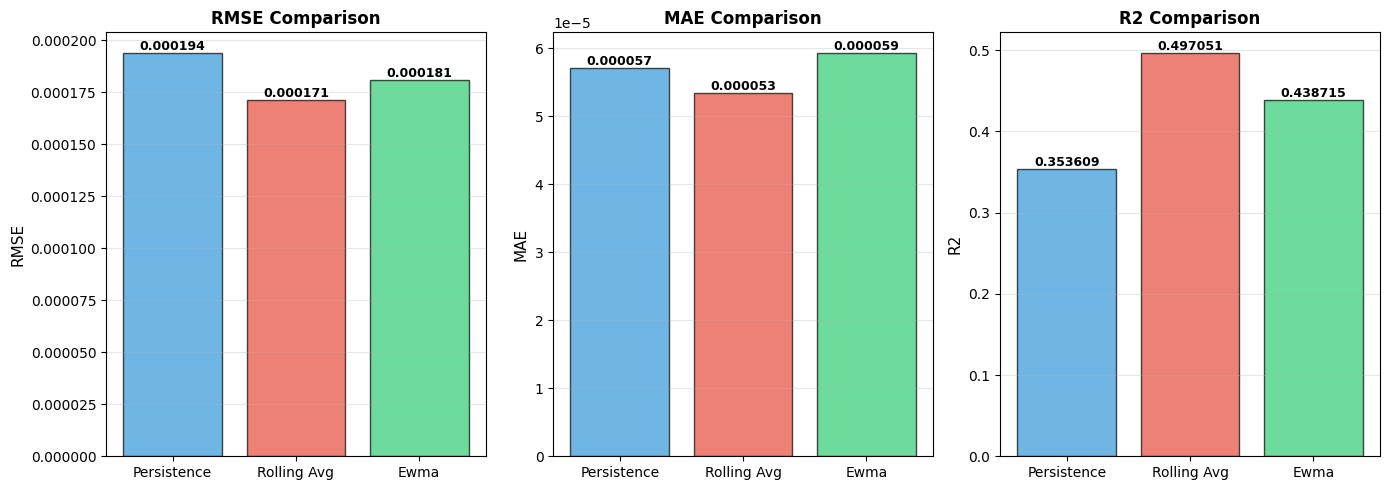

In [9]:
# Plot metric comparison
fig = plot_metrics_comparison(
    metrics_table,
    figsize=(14, 5),
    save_path=FIG_DIR / "overall_metrics_comparison.png"
)
plt.show()

---

## 8. Visualization of Baseline Forecasts

### 8.1 Time Series Comparisaon

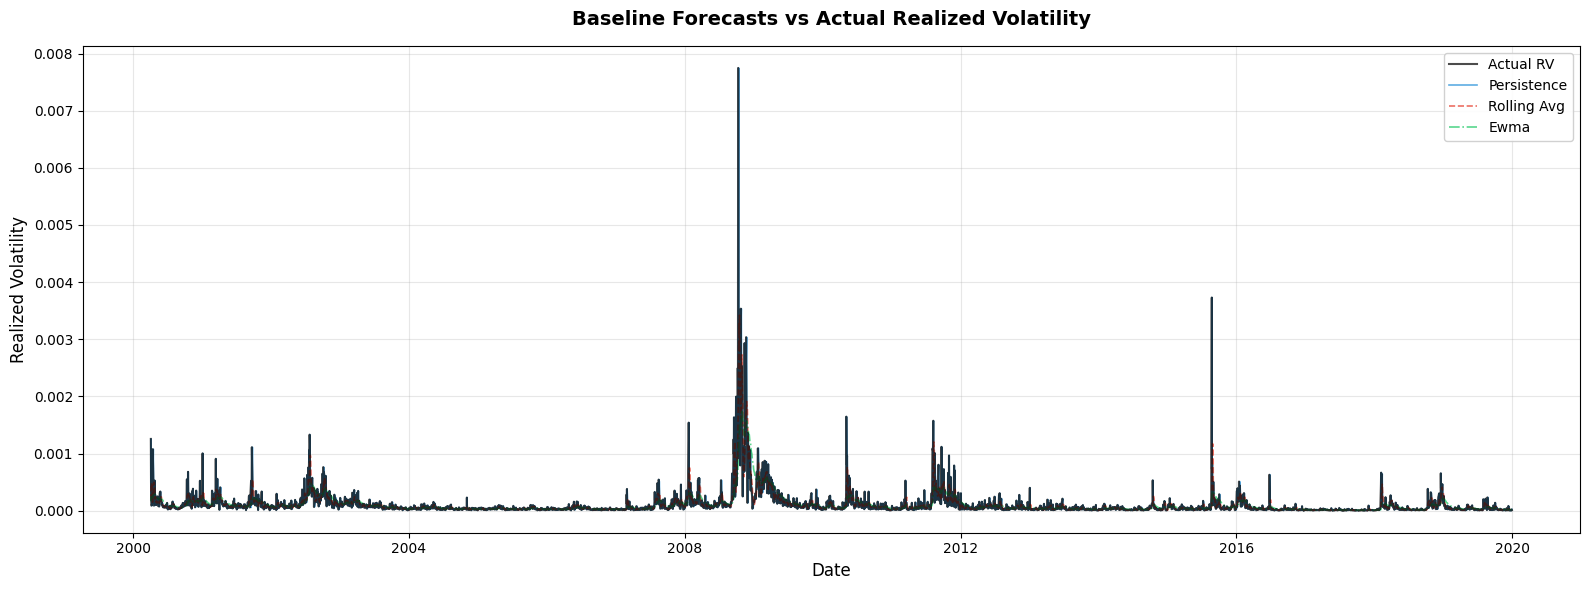

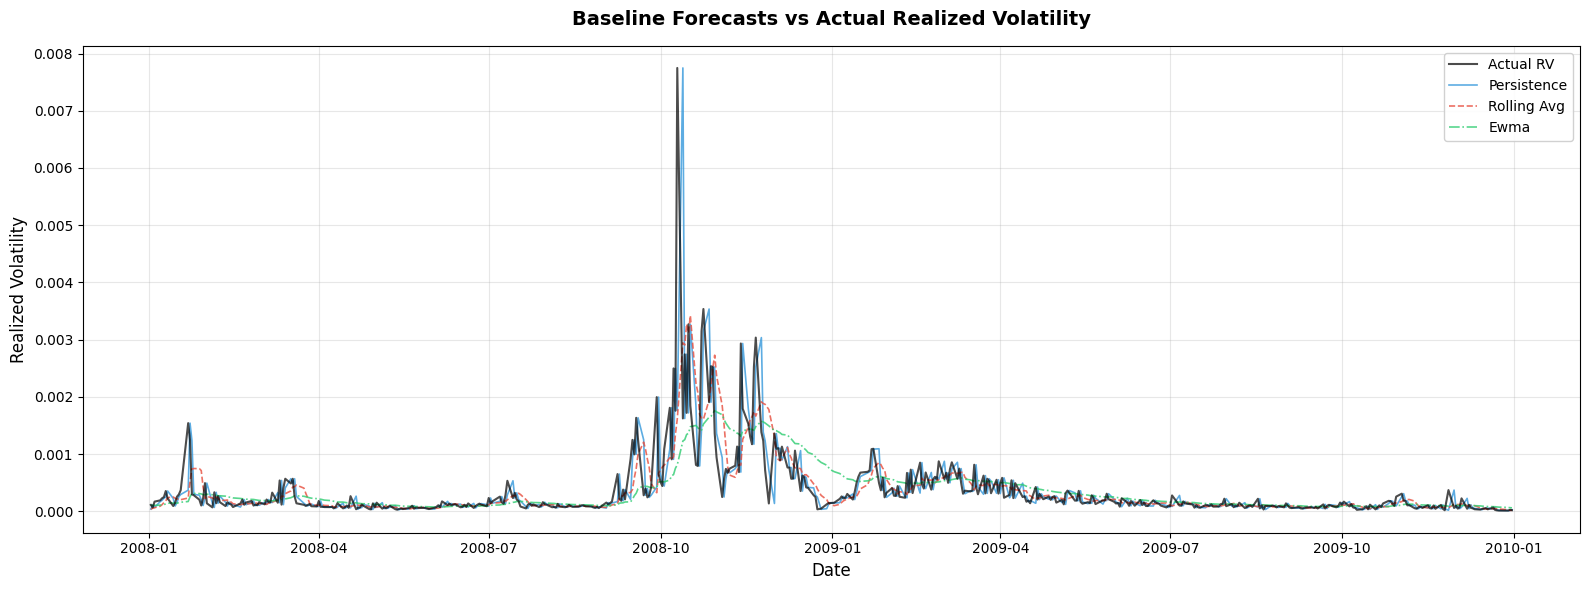

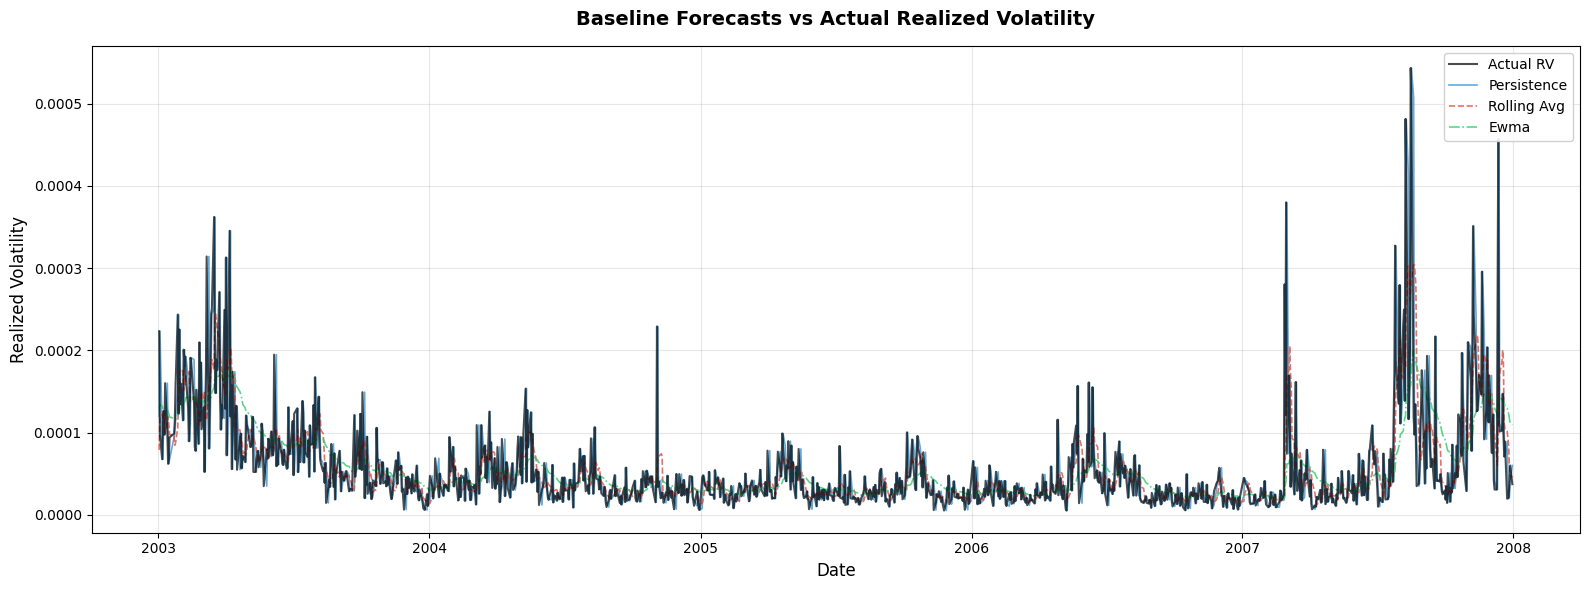

In [10]:
# Plot full time series
fig = plot_baseline_forecasts_timeseries(
    actual=eval_df['actual'],
    forecasts=eval_df[['persistence', 'rolling_avg', 'ewma']],
    figsize=(16, 6),
    save_path=FIG_DIR / "baseline_forecasts_full.png"
)
plt.show()

# Plot financial crisis period (2008-2009)
fig = plot_baseline_forecasts_timeseries(
    actual=eval_df['actual'],
    forecasts=eval_df[['persistence', 'rolling_avg', 'ewma']],
    start_date='2008-01-01',
    end_date='2009-12-31',
    figsize=(16, 6),
    save_path=FIG_DIR / "baseline_forecasts_crisis.png"
)
plt.show()

# Plot calm period (2003-2007)
fig = plot_baseline_forecasts_timeseries(
    actual=eval_df['actual'],
    forecasts=eval_df[['persistence', 'rolling_avg', 'ewma']],
    start_date='2003-01-01',
    end_date='2007-12-31',
    figsize=(16, 6),
    save_path=FIG_DIR / "baseline_forecasts_calm.png"
)
plt.show()

### Interpretation:

The time series plots reveal distinct behavioral patterns:

**Full sample:**
- All baselines track realized volatility reasonably well
- EWMA and persistence are visually very similar
- Rolling average is noticeably smoother

**Financial crisis (2008-2009):**
- All baselines lag behind extreme volatility spikes
- Persistence reacts fastest (one-day lag)
- Rolling average is excessively smooth, misses peak magnitudes
- EWMA provides middle ground

**Calm period (2003-2007):**
- All baselines perform very similarly
- Low volatility makes differences negligible
- Minimal forecast errors across all models